# Basic Details Analysis: Generation Statistics and Performance of the choosen LLM's

Extract and analyze basic generation details from JSON files for each run, model, and domain.

## Imports

In [1]:
from basic_details_analysis import *
from color_palette import *

# WARNINGS
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pkg_resources")

  1/81...
  11/81...
  21/81...
  31/81...
  41/81...
  51/81...
  61/81...
  71/81...
  81/81...


In [2]:
PROJECT_ROOT = find_project_root()
GENERATED_DIR = PROJECT_ROOT / "data" / "generated"
ANALYSIS_OUT_DIR = PROJECT_ROOT / "analysis" / "basic_details"
ANALYSIS_OUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Generated dir: {GENERATED_DIR}")
print(f"Analysis dir: {ANALYSIS_OUT_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

Project root: /Users/veronhoxha/Desktop/master_thesis
Generated dir: /Users/veronhoxha/Desktop/master_thesis/data/generated
Analysis dir: /Users/veronhoxha/Desktop/master_thesis/analysis/basic_details
Figures dir: /Users/veronhoxha/Desktop/master_thesis/figures


## Discover all generation summary JSON files

In [3]:
print(f"Found {len(summary_files)} generation summary files")
print(f"Models: {sorted(set(f['model'] for f in summary_files))}")
print(f"Domains: {sorted(set(f['domain'] for f in summary_files))}")
print(f"Shots: {sorted(set(f['shot'] for f in summary_files))}")
print(f"Runs: {sorted(set(f['run_num'] for f in summary_files if f['run_num'] is not None))}")

Found 81 generation summary files
Models: ['kimi-k2-instruct-0905', 'llama-3.1-8b-instruct', 'qwen3-coder-30b-a3b-instruct']
Domains: ['employment', 'hatecrime', 'lending']
Shots: ['few', 'one', 'zero']
Runs: [1, 2, 3]


## Basic details of the data generation from the chosen LLM's

In [4]:
print(f"\n=== BASIC DATA ===")
sample_cols = ['model', 'domain', 'shot_type', 'run_num', 'achieved_rows', 'duration_s', 'total_chunks', 'success_rate']
print("\n")
print(details_df[sample_cols].to_string(index=False))


=== BASIC DATA ===


                            model     domain shot_type  run_num  achieved_rows  duration_s  total_chunks  success_rate
 moonshotai/Kimi-K2-Instruct-0905 employment       few        1           1032      284.77            20      1.000000
 moonshotai/Kimi-K2-Instruct-0905 employment       one        1           1025      281.56            21      1.000000
 moonshotai/Kimi-K2-Instruct-0905 employment      zero        1           1043      247.53            22      1.000000
 moonshotai/Kimi-K2-Instruct-0905  hatecrime       few        1           1004      180.52            21      1.000000
 moonshotai/Kimi-K2-Instruct-0905  hatecrime       one        1           1000      167.57            21      1.000000
 moonshotai/Kimi-K2-Instruct-0905  hatecrime      zero        1           1042      168.43            22      1.000000
 moonshotai/Kimi-K2-Instruct-0905    lending       few        1           1035      430.42            24      1.000000
 moonshotai/Kimi-K2-Instru

## Time progression analysis

In [5]:
chunk_df = load_chunk_timing_data()

In [6]:
models_present = chunk_df['model'].unique() if 'chunk_df' in locals() else []
model_colors = {model: model_color(model) for model in models_present}

In [7]:
print("="*80)
print("TIME PROGRESSION ACROSS CHUNKS")
print("="*80)

if len(chunk_df) > 0:
    # calculate average time per chunk across runs for each model
    chunk_timing = chunk_df.groupby(['model', 'chunk_id'])['duration_s'].mean().reset_index()
    models = ordered_levels(chunk_df['model'].unique(), MODEL_ORDER)
    domains = ordered_levels(chunk_df['domain'].unique(), DOMAIN_ORDER)
    shot_types = ordered_levels(chunk_df['shot_type'].unique(), SHOT_ORDER)
    
    print(f"\nChunk timing summary:")
    print(f"Models: {models}")
    print(f"Domains: {domains}")
    print(f"Shot types: {shot_types}")
    print(f"Runs per combination: {chunk_df.groupby(['model', 'domain', 'shot_type'])['run_num'].nunique().iloc[0]}")
    print(f"Chunk range: {chunk_df['chunk_id'].min()} to {chunk_df['chunk_id'].max()}")
    print(f"Average chunks per model: {chunk_df.groupby('model')['chunk_id'].nunique().mean():.1f}")
    print(f"Total chunks analyzed: {len(chunk_df)}")
    
    # show sample data
    print(f"\nChunk timing data (averaged across runs):")
    sample_cols = ['model', 'chunk_id', 'duration_s']
    print(chunk_timing[sample_cols].to_string(index=False))
    
else:
    print("No chunk timing data available")

TIME PROGRESSION ACROSS CHUNKS

Chunk timing summary:
Models: ['kimi-k2-instruct-0905', 'llama-3.1-8b-instruct', 'qwen3-coder-30b-a3b-instruct']
Domains: ['hatecrime', 'employment', 'lending']
Shot types: ['zero', 'one', 'few']
Runs per combination: 3
Chunk range: 1 to 29
Average chunks per model: 27.3
Total chunks analyzed: 1788

Chunk timing data (averaged across runs):
                       model  chunk_id  duration_s
       kimi-k2-instruct-0905         1   12.422593
       kimi-k2-instruct-0905         2   13.000741
       kimi-k2-instruct-0905         3   12.357778
       kimi-k2-instruct-0905         4   12.520000
       kimi-k2-instruct-0905         5   12.958519
       kimi-k2-instruct-0905         6   12.640370
       kimi-k2-instruct-0905         7   13.038148
       kimi-k2-instruct-0905         8   12.530000
       kimi-k2-instruct-0905         9   12.615185
       kimi-k2-instruct-0905        10   13.078148
       kimi-k2-instruct-0905        11   12.959630
       kimi-k

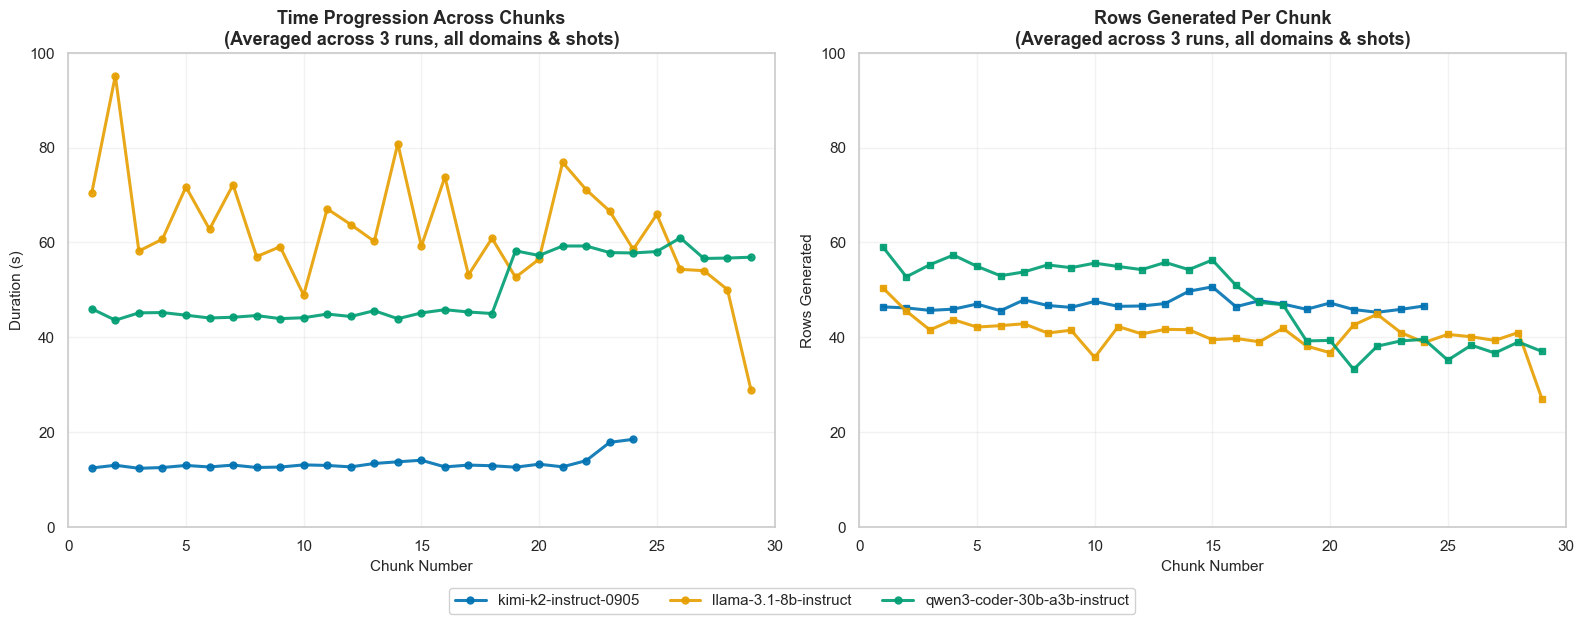


=== TIME PROGRESSION SUMMARY ===
kimi-k2-instruct-0905:
  First chunk: 12.4s, Last chunk: 18.5s
  Average time: 13.4s

llama-3.1-8b-instruct:
  First chunk: 70.5s, Last chunk: 28.9s
  Average time: 62.4s

qwen3-coder-30b-a3b-instruct:
  First chunk: 46.0s, Last chunk: 56.9s
  Average time: 49.8s



In [8]:
if len(chunk_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax1, ax2 = axes
    model_sequence = ordered_levels(chunk_df['model'].unique(), MODEL_ORDER)

    for model in model_sequence:
        model_data = chunk_timing[chunk_timing['model'] == model]
        if len(model_data) > 0:
            ax1.plot(
                model_data['chunk_id'], model_data['duration_s'],
                marker='o', markersize=5, linewidth=2.2,
                color=model_colors[model], label=model, alpha=0.9
            )

    ax1.set_title('Time Progression Across Chunks\n(Averaged across 3 runs, all domains & shots)',
                  fontweight='bold', fontsize=13)
    ax1.set_xlabel('Chunk Number', fontsize=11)
    ax1.set_ylabel('Duration (s)', fontsize=11)
    ax1.grid(alpha=0.25)
    ax1.set_xlim(left=0, right=30)
    ax1.set_ylim(bottom=0, top=100)

    chunk_rows = chunk_df.groupby(['model', 'chunk_id'])['rows_generated'].mean().reset_index()
    for model in model_sequence:
        model_data = chunk_rows[chunk_rows['model'] == model]
        if len(model_data) > 0:
            ax2.plot(
                model_data['chunk_id'], model_data['rows_generated'],
                marker='s', markersize=5, linewidth=2.2,
                color=model_colors[model], label=model, alpha=0.9
            )

    ax2.set_title('Rows Generated Per Chunk\n(Averaged across 3 runs, all domains & shots)',
                  fontweight='bold', fontsize=13)
    ax2.set_xlabel('Chunk Number', fontsize=11)
    ax2.set_ylabel('Rows Generated', fontsize=11)
    ax2.grid(alpha=0.25)
    ax2.set_xlim(left=0, right=30)
    ax2.set_ylim(bottom=0, top=100)
    ax2.set_ylim(bottom=0, top=100)
    
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        ncol=len(labels),
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        frameon=True,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "time_progression_accros_chunks_and_rows_generated_per_chunk.png", bbox_inches='tight')
    plt.show()

    print(f"\n=== TIME PROGRESSION SUMMARY ===")
    for model in model_sequence:
        model_data = chunk_timing[chunk_timing['model'] == model]
        if len(model_data) > 1:
            first_chunk_time = model_data.loc[model_data['chunk_id'].idxmin(), 'duration_s']
            last_chunk_time = model_data.loc[model_data['chunk_id'].idxmax(), 'duration_s']
            avg_time = model_data['duration_s'].mean()

            print(f"{model}:")
            print(f"  First chunk: {first_chunk_time:.1f}s, Last chunk: {last_chunk_time:.1f}s")
            print(f"  Average time: {avg_time:.1f}s\n")

else:
    print("Cannot generate time progression plots - no chunk data available")

TIME PROGRESSION BY DOMAIN AND SHOT TYPE
(Averaged across 3 runs for each model/domain/shot combination)


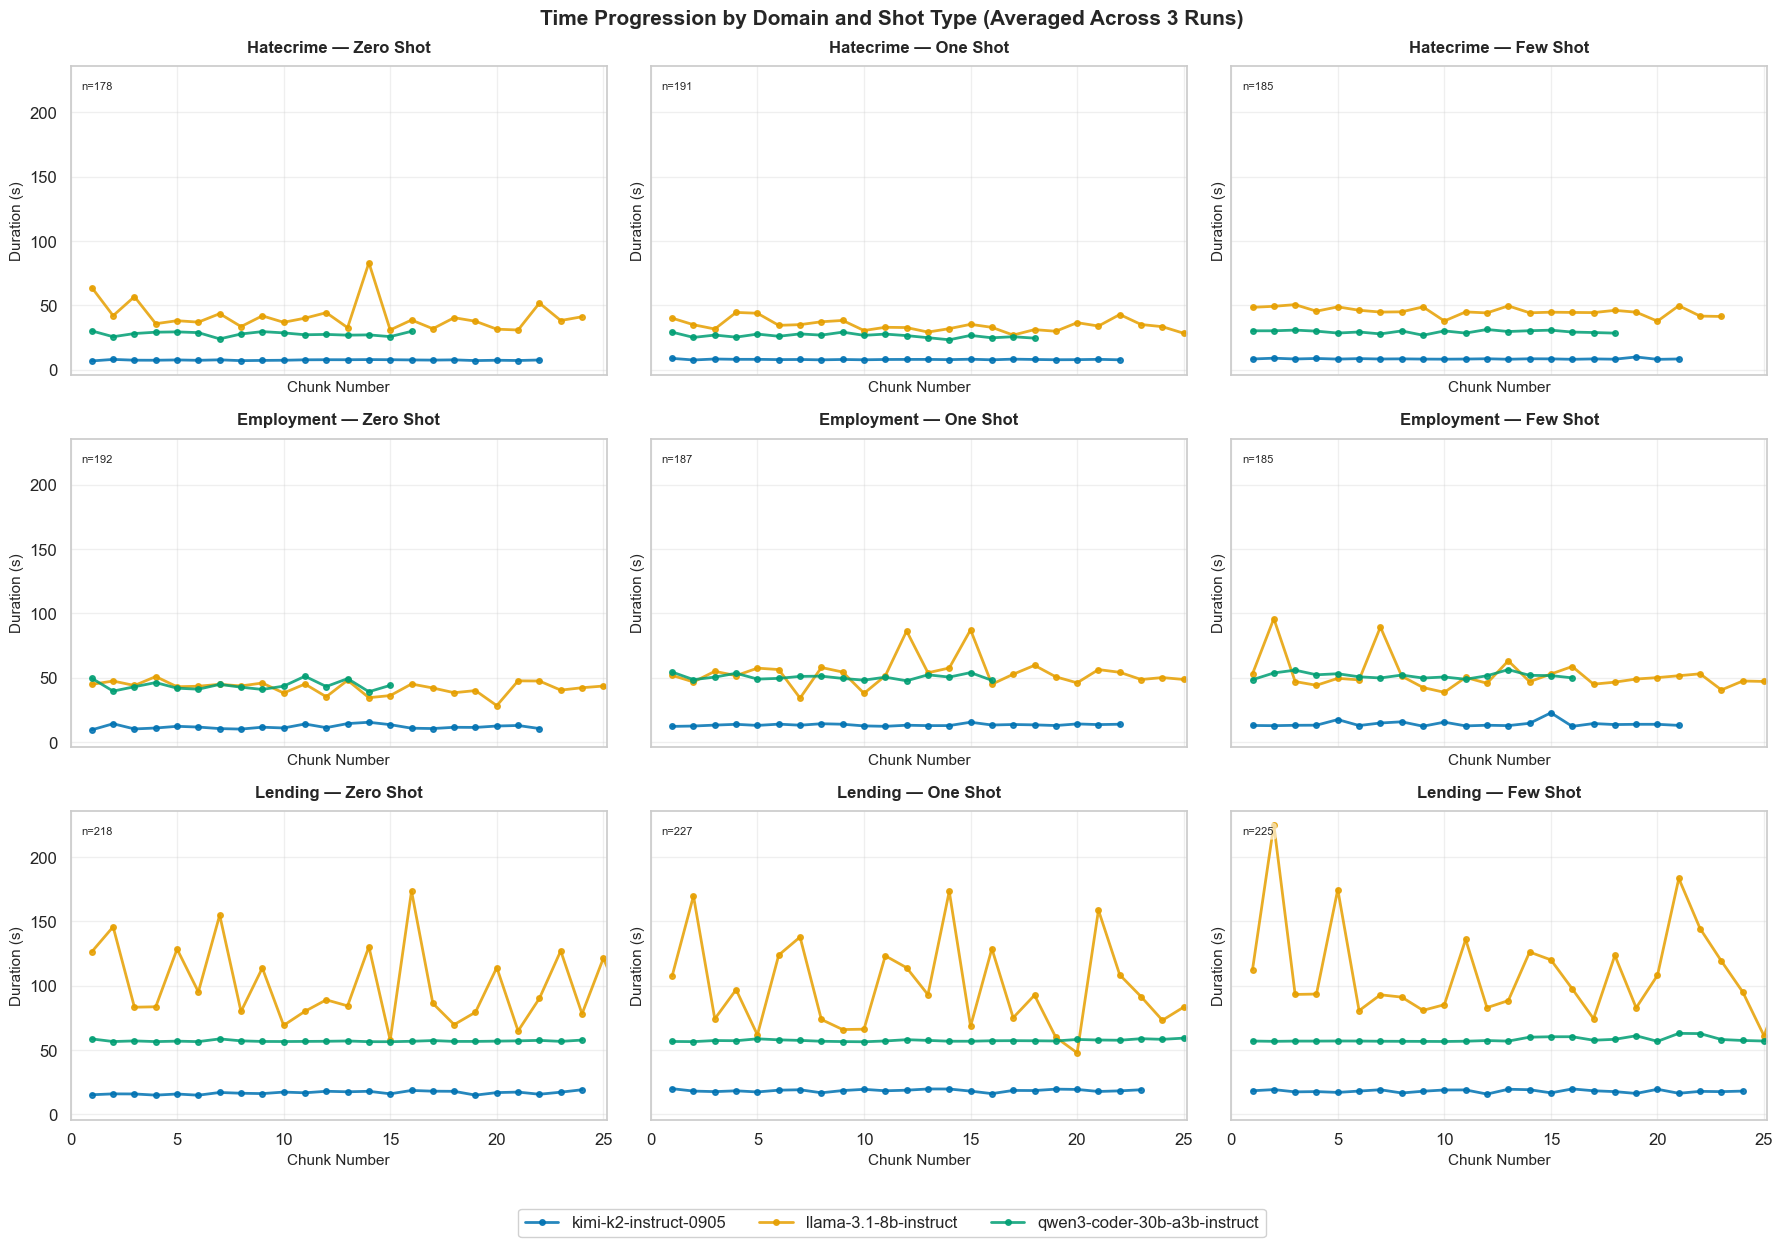


=== TIME PROGRESSION PATTERNS ===
                       model     domain shot  first_chunk_s  last_chunk_s  avg_time_s
       kimi-k2-instruct-0905  hatecrime zero           6.81          7.55        7.48
       kimi-k2-instruct-0905  hatecrime  one           8.80          7.70        7.96
       kimi-k2-instruct-0905  hatecrime  few           8.33          8.34        8.44
       kimi-k2-instruct-0905 employment zero           9.45         10.46       11.79
       kimi-k2-instruct-0905 employment  one          12.13         13.82       13.29
       kimi-k2-instruct-0905 employment  few          12.85         12.91       14.10
       kimi-k2-instruct-0905    lending zero          15.20         19.10       16.69
       kimi-k2-instruct-0905    lending  one          19.91         19.09       18.49
       kimi-k2-instruct-0905    lending  few          18.30         18.05       17.97
       llama-3.1-8b-instruct  hatecrime zero          63.84         41.15       41.76
       llama-3.1-8b

In [9]:
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 15,
    'axes.titlepad': 10,
})

if len(chunk_df) > 0:
    print("="*80)
    print("TIME PROGRESSION BY DOMAIN AND SHOT TYPE")
    print("(Averaged across 3 runs for each model/domain/shot combination)")
    print("="*80)
    
    domains = ordered_levels(chunk_df['domain'].unique(), DOMAIN_ORDER)
    shot_types = ordered_levels(chunk_df['shot_type'].unique(), SHOT_ORDER)
    
    fig, axes = plt.subplots(
        len(domains), len(shot_types),
        figsize=(18, 12),
        sharex=True, sharey=True
    )
    
    if len(domains) == 1 and len(shot_types) == 1:
        axes = [[axes]]
    elif len(domains) == 1:
        axes = [axes]
    elif len(shot_types) == 1:
        axes = [[ax] for ax in axes]

    for row, domain in enumerate(domains):
        for col, shot in enumerate(shot_types):
            ax = axes[row][col]
            domain_shot_data = chunk_df[(chunk_df['domain'] == domain) & (chunk_df['shot_type'] == shot)]
            
            if len(domain_shot_data) > 0:
                domain_shot_timing = (
                    domain_shot_data.groupby(['model', 'chunk_id'])['duration_s']
                    .mean()
                    .reset_index()
                )

                for model in ordered_levels(domain_shot_data['model'].unique(), MODEL_ORDER):
                    model_data = domain_shot_timing[domain_shot_timing['model'] == model]
                    ax.plot(
                        model_data['chunk_id'], model_data['duration_s'],
                        marker='o', linewidth=2, markersize=4,
                        label=model, color=model_colors[model], alpha=0.85
                    )
                
                ax.set_title(f'{domain.title()} — {shot.title()} Shot', weight='bold')
                ax.set_xlabel('Chunk Number')
                ax.set_ylabel('Duration (s)')
                ax.grid(True, which='major', alpha=0.3)
                ax.set_xlim(left=0)
                
                total_chunks = len(domain_shot_data)
                ax.text(
                    0.02, 0.95, f'n={total_chunks}',
                    transform=ax.transAxes,
                    fontsize=8, va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6, edgecolor='none')
                )
            else:
                ax.set_title(f'{domain.title()} — {shot.title()} Shot', weight='bold')
                ax.text(
                    0.5, 0.5, 'No data available',
                    ha='center', va='center', fontsize=9, color='gray', transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])

    fig.suptitle(
        "Time Progression by Domain and Shot Type (Averaged Across 3 Runs)",
        weight='bold',
        fontsize=15
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        ncol=len(labels),
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        frameon=True,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "time_progression_by_domain_shot.png", bbox_inches='tight')
    plt.show()
    
    # summary table for time progression patterns
    print(f"\n=== TIME PROGRESSION PATTERNS ===")
    progression_summary = []
    
    for model in ordered_levels(chunk_df['model'].unique(), MODEL_ORDER):
        for domain in domains:
            for shot in shot_types:
                domain_shot_data = chunk_df[(chunk_df['model'] == model) & 
                                          (chunk_df['domain'] == domain) & 
                                          (chunk_df['shot_type'] == shot)]
                
                if len(domain_shot_data) > 1:
                    chunk_timing = domain_shot_data.groupby('chunk_id')['duration_s'].mean()
                    if len(chunk_timing) > 1:
                        first_time = chunk_timing.iloc[0]
                        last_time = chunk_timing.iloc[-1]
                        avg_time = chunk_timing.mean()
                        
                        progression_summary.append({
                            'model': model,
                            'domain': domain,
                            'shot': shot,
                            'first_chunk_s': first_time.round(2),
                            'last_chunk_s': last_time.round(2),
                            'avg_time_s': avg_time.round(2),
                        })
    
    if progression_summary:
        progression_df = pd.DataFrame(progression_summary)
        print(progression_df.to_string(index=False))
        
        progression_file = ANALYSIS_OUT_DIR / "time_progression_analysis.csv"
        progression_df.to_csv(progression_file, index=False)
        print(f"\nSaved time progression analysis to: {progression_file}")
    else:
        print("No time progression data available for analysis")
else:
    print("No chunk data available for time progression analysis")

## Row Generation Analysis

**Key Questions**:
- How many rows did each model generate per domain/shot?
- Did models achieve their target row counts?
- How consistent are row counts across runs?


In [10]:
# row generation summary by model, domain, and shot
print("=== ROW GENERATION SUMMARY ===")

# overall summary
row_summary = details_df.groupby(['model', 'domain', 'shot_type']).agg({
    'achieved_rows': ['mean', 'std', 'min', 'max', 'count'],
    'target_rows': 'first',
    'duration_s': ['mean', 'std']
}).round(2)

print("\nRows Generated (Mean ± Std, Min-Max, Count):")
print(row_summary.to_string())

# target achievement analysis of rows
details_df['target_achievement'] = details_df['achieved_rows'] / details_df['target_rows']
print(f"\n=== TARGET ACHIEVEMENT ===")
target_achievement = details_df.groupby(['model', 'domain', 'shot_type'])['target_achievement'].agg(['mean', 'std', 'min', 'max']).round(3)
print(target_achievement.to_string())

# consistency across runs the runs in row generation
print(f"\n=== CONSISTENCY ACROSS RUNS ===")
consistency = details_df.groupby(['model', 'domain', 'shot_type'])['achieved_rows'].agg(['std', 'mean']).round(2)
consistency['cv'] = (consistency['std'] / consistency['mean'] * 100).round(2)
consistency = consistency.sort_values('cv')
print("Coefficient of Variation (CV) - Lower = More Consistent:")
print(consistency[['cv']].to_string())


=== ROW GENERATION SUMMARY ===

Rows Generated (Mean ± Std, Min-Max, Count):
                                                       achieved_rows                          target_rows duration_s        
                                                                mean    std   min   max count       first       mean     std
model                             domain     shot_type                                                                      
Qwen/Qwen3-Coder-30B-A3B-Instruct employment few             1049.33  17.56  1031  1066     3        1000     825.71    6.43
                                             one             1030.00  18.19  1019  1051     3        1000     807.21   10.97
                                             zero            1018.33   8.50  1010  1027     3        1000     659.28   33.86
                                  hatecrime  few             1035.67   3.79  1033  1040     3        1000     530.89    6.14
                                             one

## Average chunks used by model per domain and shot type

In [11]:
print("="*80)
print("AVERAGE CHUNKS USED BY MODEL PER DOMAIN AND SHOT TYPE")
print("="*80)

if len(details_df) > 0:
    # calculating average chunks by model, domain, and shot type
    chunks_analysis = details_df.groupby(['model', 'domain', 'shot_type']).agg({
        'total_chunks': ['mean', 'std', 'min', 'max', 'count']
    }).round(2)
    
    chunks_analysis.columns = ['_'.join(col).strip('_') for col in chunks_analysis.columns]
    
    print("Average chunks used (Mean ± Std, Min-Max, Count):")
    print(chunks_analysis.to_string())
    
    # creating pivot table for easier reading
    print(f"\n=== PIVOT TABLE: Average Chunks by Model and Domain ===")
    chunks_pivot = details_df.groupby(['model', 'domain'])['total_chunks'].mean().unstack().round(2)
    print("Employment | Hatecrime | Lending")
    print(chunks_pivot.to_string())
    
    print(f"\n=== PIVOT TABLE: Average Chunks by Model and Shot Type ===")
    chunks_shot_pivot = details_df.groupby(['model', 'shot_type'])['total_chunks'].mean().unstack().round(2)
    print("Zero-shot | One-shot | Few-shot")
    print(chunks_shot_pivot.to_string())
    
    # detailed breakdown by domain and shot type
    print(f"\n=== DETAILED BREAKDOWN ===")
    for domain in sorted(details_df['domain'].unique()):
        print(f"\n{domain.upper()} DOMAIN:")
        domain_data = details_df[details_df['domain'] == domain]
        domain_chunks = domain_data.groupby(['model', 'shot_type'])['total_chunks'].mean().unstack().round(2)
        print(domain_chunks.to_string())
    
    # summary statistics
    print(f"\n=== SUMMARY STATISTICS ===")
    overall_stats = details_df.groupby('model')['total_chunks'].agg(['mean', 'std', 'min', 'max']).round(2)
    print("Overall chunks per model:")
    print(overall_stats.to_string())
    
    # domain specific statistics
    print(f"\nChunks by domain:")
    domain_stats = details_df.groupby('domain')['total_chunks'].agg(['mean', 'std']).round(2)
    print(domain_stats.to_string())
    
    # shot type statistics
    print(f"\nChunks by shot type:")
    shot_stats = details_df.groupby('shot_type')['total_chunks'].agg(['mean', 'std']).round(2)
    print(shot_stats.to_string())
    
    # saving chunks analysis
    chunks_file = ANALYSIS_OUT_DIR / "chunks_analysis.csv"
    chunks_analysis.to_csv(chunks_file)
    print(f"\nSaved chunks analysis to: {chunks_file}")
    
else:
    print("No data available for chunks analysis")

AVERAGE CHUNKS USED BY MODEL PER DOMAIN AND SHOT TYPE
Average chunks used (Mean ± Std, Min-Max, Count):
                                                        total_chunks_mean  total_chunks_std  total_chunks_min  total_chunks_max  total_chunks_count
model                             domain     shot_type                                                                                             
Qwen/Qwen3-Coder-30B-A3B-Instruct employment few                    16.00              0.00                16                16                   3
                                             one                    16.00              0.00                16                16                   3
                                             zero                   15.00              0.00                15                15                   3
                                  hatecrime  few                    18.00              0.00                18                18                   3
        

## Quality of Rows generated

In [12]:
raw_analysis_df = analyze_raw_finals_comprehensive()

In [13]:
if not raw_analysis_df.empty:
    total_original_rows = raw_analysis_df['total_data_rows'].sum()
    total_pandas_rows = raw_analysis_df['pandas_readable_rows'].sum()
    total_lost = raw_analysis_df['total_rows_lost'].sum()
    print(f"Total original data rows: {total_original_rows:,}")
    print(f"Total pandas-readable rows: {total_pandas_rows:,}")
    print(f"Total rows lost: {total_lost:,}")
    print(f"Overall skip rate: {(total_lost/total_original_rows*100):.2f}%")

    print("\n=== BY MODEL ===")
    model_summary = raw_analysis_df.groupby('model').agg({
        'total_data_rows': 'sum',
        'pandas_readable_rows': 'sum',
        'total_rows_lost': 'sum',
    })
    print(model_summary)

    print("\n=== BY MODEL x RUN ===")
    model_run_summary = raw_analysis_df.groupby(['model', 'run_num']).agg({
        'total_data_rows': 'sum',
        'pandas_readable_rows': 'sum',
        'total_rows_lost': 'sum',
    })
    print(model_run_summary)

    print("\n--- Rows lost (pivot) — Model x Run ---")
    model_run_loss_pivot = raw_analysis_df.pivot_table(
        values='total_rows_lost', index='model', columns='run_num', aggfunc='sum', fill_value=0
    )
    print(model_run_loss_pivot)

    raw_analysis_df.to_csv(ANALYSIS_OUT_DIR / 'raw_finals_comprehensive_analysis.csv', index=False)
    print(f"\nResults saved to: {ANALYSIS_OUT_DIR / 'raw_finals_comprehensive_analysis.csv'}")
else:
    print('No raw_finals files found!')

Total original data rows: 84,235
Total pandas-readable rows: 72,247
Total rows lost: 11,988
Overall skip rate: 14.23%

=== BY MODEL ===
                              total_data_rows  pandas_readable_rows  \
model                                                                 
kimi-k2-instruct-0905                   27773                 26254   
llama-3.1-8b-instruct                   28681                 22501   
qwen3-coder-30b-a3b-instruct            27781                 23492   

                              total_rows_lost  
model                                          
kimi-k2-instruct-0905                    1519  
llama-3.1-8b-instruct                    6180  
qwen3-coder-30b-a3b-instruct             4289  

=== BY MODEL x RUN ===
                                      total_data_rows  pandas_readable_rows  \
model                        run_num                                          
kimi-k2-instruct-0905        1                   9254                  8961   
       

In [14]:
print("\n=== DETAILED BREAKDOWN (Model x Domain x Shot) ===")
detailed_summary = raw_analysis_df.groupby(['model', 'domain', 'shot_type']).agg({
    'total_data_rows': 'mean',
    'pandas_readable_rows': 'mean',
    'total_rows_lost': 'mean',
}).round(1)
print(detailed_summary)


=== DETAILED BREAKDOWN (Model x Domain x Shot) ===
                                                   total_data_rows  \
model                        domain     shot_type                    
kimi-k2-instruct-0905        employment few                 1027.7   
                                        one                 1037.3   
                                        zero                1030.0   
                             hatecrime  few                 1007.7   
                                        one                 1016.7   
                                        zero                1035.7   
                             lending    few                 1033.0   
                                        one                 1026.0   
                                        zero                1043.7   
llama-3.1-8b-instruct        employment few                 1006.7   
                                        one                 1019.3   
                                      

In [15]:
print("\n=== DETAILED BREAKDOWN (Model x Run x Domain x Shot) ===")
detailed_run_summary = raw_analysis_df.groupby(['model', 'run_num', 'domain', 'shot_type']).agg({
    'total_data_rows': 'mean',
    'pandas_readable_rows': 'mean',
    'total_rows_lost': 'mean',
})
print(detailed_run_summary)


=== DETAILED BREAKDOWN (Model x Run x Domain x Shot) ===
                                                           total_data_rows  \
model                        run_num domain     shot_type                    
kimi-k2-instruct-0905        1       employment few                 1032.0   
                                                one                 1026.0   
                                                zero                1043.0   
                                     hatecrime  few                 1004.0   
                                                one                 1000.0   
...                                                                    ...   
qwen3-coder-30b-a3b-instruct 3       hatecrime  one                 1050.0   
                                                zero                1078.0   
                                     lending    few                 1013.0   
                                                one                 1015.0   
      

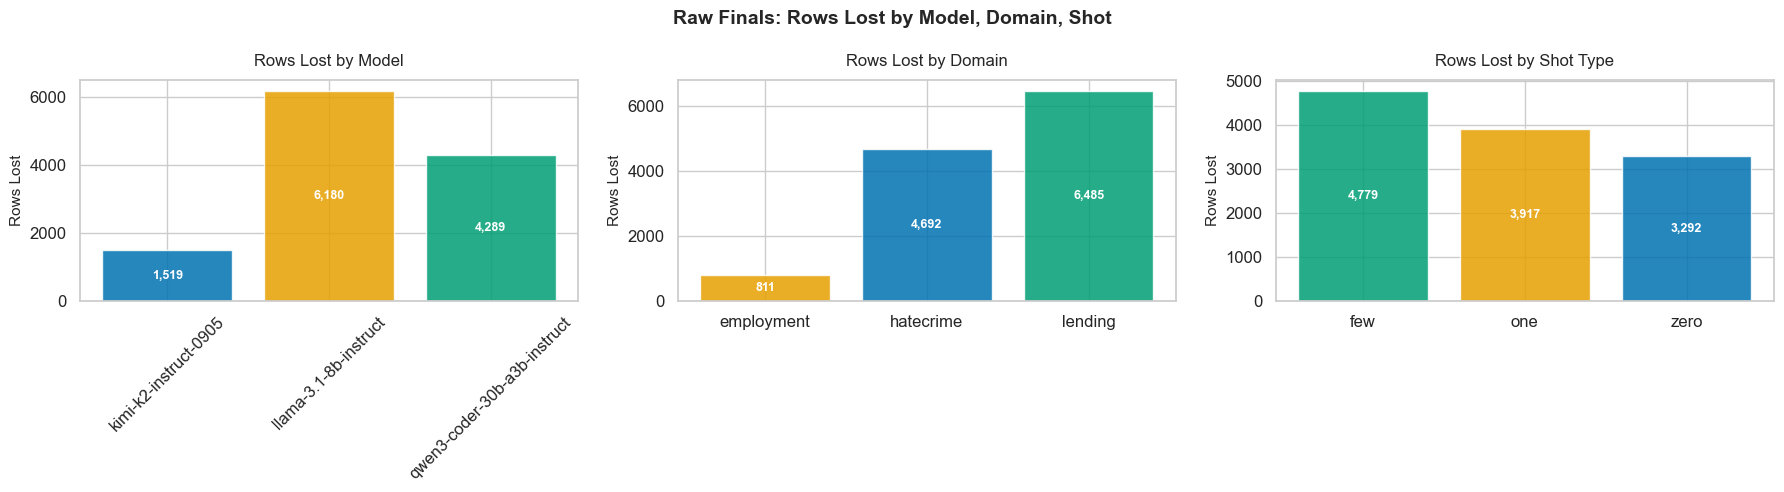

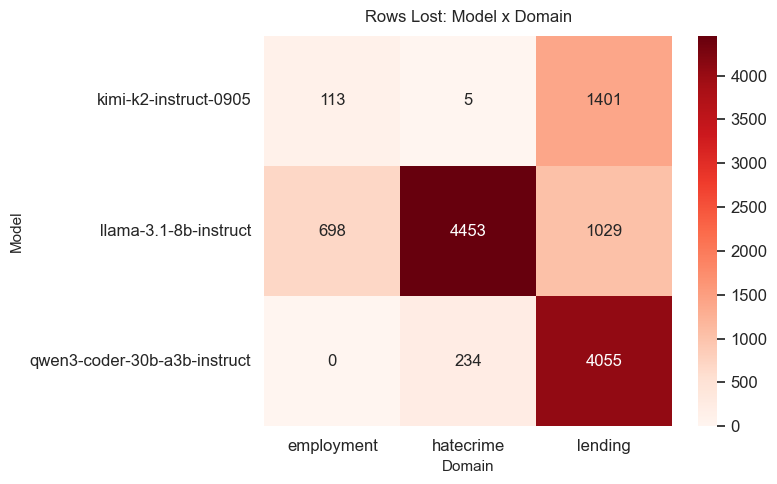


DETAILED COMPARISON TABLE
                                                   total_data_rows  pandas_readable_rows  total_rows_lost  rows_lost_pct
model                        domain     shot_type                                                                       
kimi-k2-instruct-0905        employment few                 1027.7                1026.0              1.7           0.17
                                        one                 1037.3                1025.7             11.7           1.13
                                        zero                1030.0                1005.7             24.3           2.36
                             hatecrime  few                 1007.7                1007.7              0.0           0.00
                                        one                 1016.7                1015.0              1.7           0.17
                                        zero                1035.7                1035.7              0.0           0.00
     

In [16]:
if not raw_analysis_df.empty:    

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Raw Finals: Rows Lost by Model, Domain, Shot', fontsize=14, fontweight='bold')
    
    model_loss = raw_analysis_df.groupby('model')['total_rows_lost'].sum()
    model_colors_bar = [model_color(model) for model in model_loss.index]
    bars0 = axes[0].bar(model_loss.index, model_loss.values, color=model_colors_bar, alpha=0.85)
    axes[0].set_title('Rows Lost by Model')
    axes[0].set_ylabel('Rows Lost')
    axes[0].tick_params(axis='x', rotation=45)
    for rect in bars0:
        height = rect.get_height()
        axes[0].text(rect.get_x() + rect.get_width()/2, height/2, f"{int(height):,}",
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    domain_loss = raw_analysis_df.groupby('domain')['total_rows_lost'].sum()
    domain_colors_bar = [domain_color(domain) for domain in domain_loss.index]
    bars1 = axes[1].bar(domain_loss.index, domain_loss.values, color=domain_colors_bar, alpha=0.85)
    axes[1].set_title('Rows Lost by Domain')
    axes[1].set_ylabel('Rows Lost')
    for rect in bars1:
        height = rect.get_height()
        axes[1].text(rect.get_x() + rect.get_width()/2, height/2, f"{int(height):,}",
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    shot_loss = raw_analysis_df.groupby('shot_type')['total_rows_lost'].sum()
    shot_colors_bar = [shot_color(shot) for shot in shot_loss.index]
    bars2 = axes[2].bar(shot_loss.index, shot_loss.values, color=shot_colors_bar, alpha=0.85)
    axes[2].set_title('Rows Lost by Shot Type')
    axes[2].set_ylabel('Rows Lost')
    for rect in bars2:
        height = rect.get_height()
        axes[2].text(rect.get_x() + rect.get_width()/2, height/2, f"{int(height):,}",
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "rows_lost_by_model_domain_shot.png", bbox_inches='tight')
    plt.show()
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    pivot_loss = raw_analysis_df.groupby(['model', 'domain'])['total_rows_lost'].sum().unstack(fill_value=0)
    sns.heatmap(pivot_loss, annot=True, fmt='d', cmap='Reds', ax=ax)
    ax.set_title('Rows Lost: Model x Domain')
    ax.set_xlabel('Domain')
    ax.set_ylabel('Model')   
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "rows_lost_by_model_domain.png", bbox_inches='tight')
    plt.show()
    
    
    print("\n" + "="*100)
    print("DETAILED COMPARISON TABLE")
    print("="*100)
    comparison_table = raw_analysis_df.groupby(['model', 'domain', 'shot_type']).agg({
        'total_data_rows': 'mean',
        'pandas_readable_rows': 'mean',
        'total_rows_lost': 'mean',
    }).round(1)
    comparison_table['rows_lost_pct'] = ((comparison_table['total_rows_lost'] / comparison_table['total_data_rows']) * 100).round(2)
    print(comparison_table.to_string())
    
    print(f"\n" + "="*100)
    print("KEY INSIGHTS")
    print("="*100)
    worst_model = raw_analysis_df.groupby('model')['total_rows_lost'].sum().idxmax()
    worst_domain = raw_analysis_df.groupby('domain')['total_rows_lost'].sum().idxmax()
    worst_shot = raw_analysis_df.groupby('shot_type')['total_rows_lost'].sum().idxmax()
    print(f"WORST PERFORMERS (Most Data Loss):")
    print(f"   Model: {worst_model} ({raw_analysis_df.groupby('model')['total_rows_lost'].sum()[worst_model]} rows lost)")
    print(f"   Domain: {worst_domain} ({raw_analysis_df.groupby('domain')['total_rows_lost'].sum()[worst_domain]} rows lost)")
    print(f"   Shot Type: {worst_shot} ({raw_analysis_df.groupby('shot_type')['total_rows_lost'].sum()[worst_shot]} rows lost)")
    
else:
    print("No data available for visualization")